In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("../Data/Dataset 1_EV charging reports.csv", sep=";")


df.shape
df.columns
df.info()
df.head()


<class 'pandas.DataFrame'>
RangeIndex: 6878 entries, 0 to 6877
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   session_ID         6878 non-null   int64  
 1   Garage_ID          6878 non-null   str    
 2   User_ID            6878 non-null   str    
 3   User_type          6878 non-null   str    
 4   Shared_ID          1412 non-null   str    
 5   Start_plugin       6878 non-null   str    
 6   Start_plugin_hour  6878 non-null   int64  
 7   End_plugout        6844 non-null   str    
 8   End_plugout_hour   6844 non-null   float64
 9   El_kWh             6878 non-null   str    
 10  Duration_hours     6844 non-null   str    
 11  month_plugin       6878 non-null   str    
 12  weekdays_plugin    6878 non-null   str    
 13  Plugin_category    6878 non-null   str    
 14  Duration_category  6844 non-null   str    
dtypes: float64(1), int64(2), str(12)
memory usage: 806.1 KB


,session_ID,Garage_ID,User_ID,User_type,Shared_ID,Start_plugin,Start_plugin_hour,End_plugout,End_plugout_hour,El_kWh,Duration_hours,month_plugin,weekdays_plugin,Plugin_category,Duration_category
0,1,AdO3,AdO3-4,Private,NaN,21.12.2018 10:20,10,21.12.2018 10:23,10.0,"0,3","0,05",Dec,Friday,late morning (9-12),Less than 3 hours
1,2,AdO3,AdO3-4,Private,NaN,21.12.2018 10:24,10,21.12.2018 10:32,10.0,"0,87","0,136666667",Dec,Friday,late morning (9-12),Less than 3 hours
2,3,AdO3,AdO3-4,Private,NaN,21.12.2018 11:33,11,21.12.2018 19:46,19.0,"29,87","8,216388889",Dec,Friday,late morning (9-12),Between 6 and 9 hours
3,4,AdO3,AdO3-2,Private,NaN,22.12.2018 16:15,16,23.12.2018 16:40,16.0,"15,56","24,41972222",Dec,Saturday,late afternoon (15-18),More than 18 hours
4,5,AdO3,AdO3-2,Private,NaN,24.12.2018 22:03,22,24.12.2018 23:02,23.0,"3,62","0,970555556",Dec,Monday,late evening (21-midnight),Less than 3 hours


In [2]:
df.isnull().sum()
df["Shared_ID"].value_counts(dropna=False)
df["User_type"].value_counts()



User_type
Private    5466
Shared     1412
Name: count, dtype: int64

In [3]:
df.duplicated().sum()

np.int64(0)

In [4]:
df.dtypes

pd.to_numeric(
    df["El_kWh"].str.replace(",", "."),
    errors="coerce"
).isna().sum()




np.int64(0)

In [5]:
df["Duration_hours"].head(10)
pd.to_numeric(
    df["Duration_hours"].str.replace(",", "."),
    errors="coerce"
).isna().sum()
df[df["Duration_hours"].isna()]
df_duration = df.dropna(subset = ["Duration_hours"])

In [6]:
df["El_kWh"] = pd.to_numeric(
    df["El_kWh"].str.replace(",", "."),
    errors="coerce"
)
df["Duration_hours"] = pd.to_numeric(
    df["Duration_hours"].str.replace(",", "."),
    errors = "coerce"
)
df.dtypes

session_ID             int64
Garage_ID                str
User_ID                  str
User_type                str
Shared_ID                str
Start_plugin             str
Start_plugin_hour      int64
End_plugout              str
End_plugout_hour     float64
El_kWh               float64
Duration_hours       float64
month_plugin             str
weekdays_plugin          str
Plugin_category          str
Duration_category        str
dtype: object

In [7]:
df["Start_plugin"] = pd.to_datetime(
    df["Start_plugin"], dayfirst=True
)
df["End_plugout"] = pd.to_datetime(
    df["End_plugout"],
    dayfirst= True
)

In [8]:
df.dtypes

session_ID                    int64
Garage_ID                       str
User_ID                         str
User_type                       str
Shared_ID                       str
Start_plugin         datetime64[us]
Start_plugin_hour             int64
End_plugout          datetime64[us]
End_plugout_hour            float64
El_kWh                      float64
Duration_hours              float64
month_plugin                    str
weekdays_plugin                 str
Plugin_category                 str
Duration_category               str
dtype: object

In [9]:
df["End_plugout"].head()
df.describe()

,session_ID,Start_plugin,Start_plugin_hour,End_plugout,End_plugout_hour,El_kWh,Duration_hours
count,6878.000000,6878,6878.000000,6844,6844.000000,6878.000000,6844.000000
mean,3439.500000,2019-10-01 11:38:00.218086,16.325240,2019-10-01 13:22:09.827586,12.546902,12.720744,11.504440
min,1.000000,2018-12-21 10:20:00,0.000000,2018-12-21 10:23:00,0.000000,0.010000,0.003333
25%,1720.250000,2019-08-04 21:32:15,15.000000,2019-08-04 18:50:30,7.000000,5.200000,2.789028
50%,3439.500000,2019-11-02 17:53:00,17.000000,2019-11-02 17:05:00,12.000000,9.050000,10.026250
75%,5158.750000,2019-12-19 06:15:30,19.000000,2019-12-19 07:25:30,17.000000,16.090000,15.221181
max,6878.000000,2020-01-31 20:42:00,23.000000,2020-01-31 23:53:00,23.000000,80.860000,255.029444
std,1985.651908,NaN,4.363108,NaN,5.256756,11.787938,14.148168


Text(0.5, 1.0, 'Distribution of EV Charging Energy')

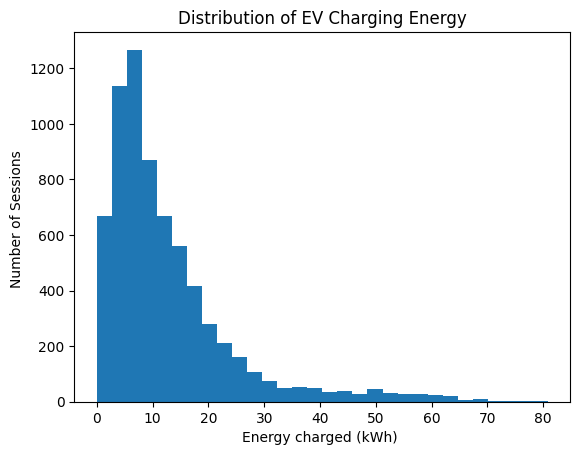

In [10]:
df["El_kWh"].plot(kind= "hist", bins = 30)
plt.xlabel("Energy charged (kWh) ")
plt.ylabel("Number of Sessions ")
plt.title("Distribution of EV Charging Energy")

In [11]:
df.groupby("User_type")["El_kWh"].agg(["count", "mean", "median"])
# we can see that shared charging sessions uses more energy than private


,count,mean,median
User_type,,,
Private,5466,11.202226,8.210
Shared,1412,18.599086,14.705


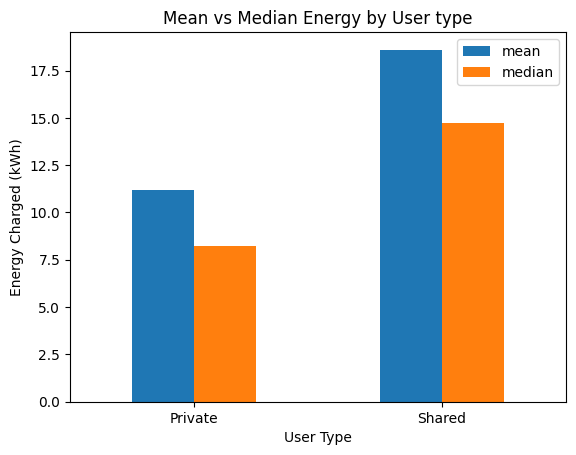

In [12]:
comparison = df.groupby("User_type")["El_kWh"].agg(["mean", "median"])
comparison.plot(kind="bar")
plt.xlabel("User Type")
plt.ylabel("Energy Charged (kWh)")
plt.title("Mean vs Median Energy by User type")
plt.xticks(rotation=0)
plt.show()

In [13]:
df.groupby("User_type")["Duration_hours"].agg(["mean", "median"])
# here we can see that private user are taking longer charging sessions


,mean,median
User_type,,
Private,12.784593,11.247500
Shared,6.535401,3.999306


In [14]:
df["Charging_Power_kW"] = df["El_kWh"]/ df["Duration_hours"]
df[["El_kWh", "Duration_hours", "Charging_Power_kW"]].head(10)

,El_kWh,Duration_hours,Charging_Power_kW
0,0.30,0.050000,6.000000
1,0.87,0.136667,6.365854
2,29.87,8.216389,3.635417
3,15.56,24.419722,0.637190
4,3.62,0.970556,3.729823
5,16.14,18.077778,0.892809
6,10.33,21.720833,0.475580
7,27.66,6.188056,4.469902
8,8.83,2.371111,3.723993
9,8.58,4.856111,1.766846


In [15]:
df.groupby("User_type")["Charging_Power_kW"].agg(["mean", "median"])
# Shared sessions tend to charge more energy in less time, which is consistent with their substantially higher average charging power.

,mean,median
User_type,,
Private,1.760431,1.140562
Shared,3.850068,3.561159


In [16]:
Hourly_Session = df["Start_plugin_hour"].value_counts().sort_index()
Hourly_Session

Start_plugin_hour
0     102
1      40
2      25
3      17
4       7
5       9
6      19
7      79
8      81
9      66
10    116
11    173
12    202
13    294
14    408
15    787
16    966
17    608
18    584
19    676
20    583
21    463
22    374
23    199
Name: count, dtype: int64

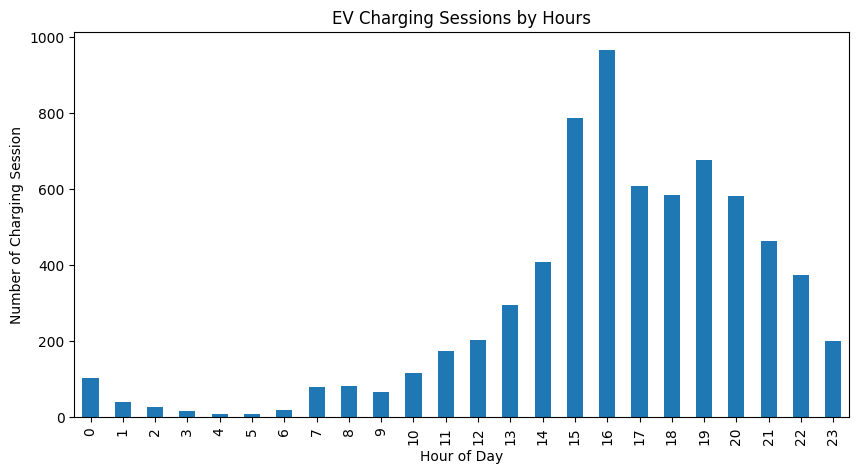

In [17]:
Hourly_Session.plot(kind= 'bar', figsize = (10,5))
plt.xlabel("Hour of Day")
plt.ylabel("Number of Charging Session")
plt.title("EV Charging Sessions by Hours")

plt.show()

In [18]:
Weekdays_Session = df["weekdays_plugin"].value_counts()
Weekdays_Session

weekdays_plugin
Thursday     1072
Wednesday    1039
Friday       1034
Monday        981
Sunday        955
Tuesday       943
Saturday      854
Name: count, dtype: int64

In [19]:
df.groupby("weekdays_plugin")["El_kWh"].agg(["count", "mean", "median"])
# Thursday has the most charging sessions (1,072), but Sunday has a higher average energy per session (14.78 kWh vs 13.08 kWh on Thursday).

,count,mean,median
weekdays_plugin,,,
Friday,1034,11.918356,8.485
Monday,981,11.998614,8.890
Saturday,854,12.530164,8.460
Sunday,955,14.779414,10.470
Thursday,1072,13.078284,9.240
Tuesday,943,12.315323,9.140
Wednesday,1039,12.464572,9.040


In [20]:
df.groupby("weekdays_plugin")["Duration_hours"].agg(["count", "mean", "median"])
# Thursday has higher charging activity by session count, while Sunday sessions tend to involve more energy and longer charging durations.

,count,mean,median
weekdays_plugin,,,
Friday,1034,13.390919,9.959167
Monday,968,11.432806,9.812222
Saturday,853,13.914938,10.673056
Sunday,953,11.146042,10.558333
Thursday,1063,10.450388,9.613056
Tuesday,936,10.375343,10.211111
Wednesday,1037,10.136469,9.935556


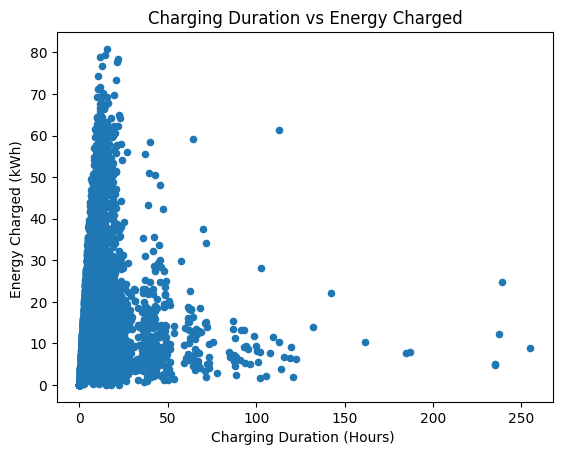

In [21]:
df.plot(x= "Duration_hours", y= "El_kWh", kind= "scatter")
plt.xlabel("Charging Duration (Hours) ")
plt.ylabel("Energy Charged (kWh) ")
plt.title("Charging Duration vs Energy Charged")

plt.show()

In [22]:
df[["Duration_hours", "El_kWh"]].corr()

,Duration_hours,El_kWh
Duration_hours,1.000000,0.105448
El_kWh,0.105448,1.000000


In [23]:
df["Charging_Power_kW"].describe()

count    6844.000000
mean        2.188495
std         1.911073
min         0.000559
25%         0.632675
50%         1.515267
75%         3.515889
max         7.776832
Name: Charging_Power_kW, dtype: float64

In [24]:
Garage_Session = df["Garage_ID"].value_counts()
Garage_Session

Garage_ID
Bl2      2243
AsO2      665
AdO1      586
UT9       421
AdO3      379
UT7       313
MS1       270
AsO10     253
NR1       224
SR2       221
MS22      187
UT15      170
UT1       166
AdA6      156
Ris       107
SR14      105
AsO8      104
AsO4      103
AdA1       97
AsO6       39
UT2        28
Bl7        19
MS11       14
SR4         8
Name: count, dtype: int64

In [25]:
garage_energy = df.groupby("Garage_ID")["El_kWh"].agg(["count", "sum", "mean"])

garage_energy.sort_values("sum", ascending=False)

,count,sum,mean
Garage_ID,,,
Bl2,2243,27046.92,12.058368
AsO2,665,10672.16,16.048361
AdO1,586,8372.83,14.288106
UT9,421,6789.82,16.127838
AdO3,379,5239.22,13.823799
SR14,105,3791.26,36.107238
SR2,221,3768.99,17.054253
AsO10,253,3428.27,13.550474
MS22,187,2651.19,14.177487


In [26]:
df[df["Garage_ID"] == "Bl7"][[
    "El_kWh",
    "Duration_hours",
    "Charging_Power_kW"
]].describe()

,El_kWh,Duration_hours,Charging_Power_kW
count,19.000000,19.000000,19.000000
mean,45.576842,12.683114,4.518383
std,19.572153,8.777486,1.687195
min,2.610000,0.386111,1.292480
25%,42.195000,9.887778,3.635601
50%,51.030000,11.722500,4.121412
75%,58.110000,13.892222,5.949745
max,63.300000,39.482222,6.994113


In [27]:
garage_analysis = df.groupby("Garage_ID")["El_kWh"].agg(
    sessions="count",
    avg_energy="mean"
)

garage_analysis[garage_analysis["sessions"] >= 50].sort_values(
    "avg_energy",
    ascending=False
)
# Session volume ≠ charging intensity.


,sessions,avg_energy
Garage_ID,,
SR14,105,36.107238
SR2,221,17.054253
UT9,421,16.127838
AsO2,665,16.048361
AdO1,586,14.288106
MS22,187,14.177487
AdO3,379,13.823799
AsO10,253,13.550474
Bl2,2243,12.058368


In [28]:
df[df["Garage_ID"]== "SR14" ].groupby("User_type")["El_kWh"].agg(["count", "mean", "median"])

,count,mean,median
User_type,,,
Private,105,36.107238,38.11


In [29]:
df[df["Garage_ID"]== "SR14"]["El_kWh"].describe()
# SR14 shows consistently high energy consumption per session compared with the other garages in our dataset.

count    105.000000
mean      36.107238
std       17.225699
min        0.110000
25%       24.000000
50%       38.110000
75%       48.870000
max       67.040000
Name: El_kWh, dtype: float64

In [30]:
df[[
    "Duration_hours",
    "Start_plugin_hour",
    "User_type",
    "Garage_ID",
    "weekdays_plugin",
    "El_kWh"
]].head()


,Duration_hours,Start_plugin_hour,User_type,Garage_ID,weekdays_plugin,El_kWh
0,0.050000,10,Private,AdO3,Friday,0.30
1,0.136667,10,Private,AdO3,Friday,0.87
2,8.216389,11,Private,AdO3,Friday,29.87
3,24.419722,16,Private,AdO3,Saturday,15.56
4,0.970556,22,Private,AdO3,Monday,3.62


In [31]:
df[["User_type", "Garage_ID", "weekdays_plugin"]].nunique()


User_type           2
Garage_ID          24
weekdays_plugin     7
dtype: int64

In [32]:
df.loc[df["Duration_hours"].isna(), "El_kWh"].isna().sum()


np.int64(0)

In [33]:
df_ml = df.dropna(subset=["Duration_hours"]).copy()

In [34]:
df_ml.shape

(6844, 16)

In [35]:
features = [
    "Duration_hours",
    "Start_plugin_hour",
    "User_type",
    "Garage_ID",
    "weekdays_plugin"
]

X = df_ml[features]
y = df_ml["El_kWh"]


print(X.shape)
print(y.shape)

(6844, 5)
(6844,)


In [36]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size= 0.2,
    random_state= 42
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (5475, 5)
Testing: (1369, 5)


In [37]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

numerical_features = [
    "Duration_hours",
    "Start_plugin_hour"
    ]
categorical_features = [
    "User_type",
    "Garage_ID",
    "weekdays_plugin"
    ]

In [38]:
X_train_encoded = pd.get_dummies(
    X_train,
    columns=categorical_features,
    drop_first=True
)

X_test_encoded = pd.get_dummies(
    X_test,
    columns=categorical_features,
    drop_first=True
)

X_test_encoded = X_test_encoded.reindex(
    columns=X_train_encoded.columns,
    fill_value=0
)

In [39]:

from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train_encoded, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [40]:
y_pred = model.predict(X_test_encoded)
print(y_pred[:10])

[ 8.242  15.7121 24.9674  7.2438  6.4494 15.5437  7.2502 10.5637  9.9889
 36.3944]


In [41]:
print(y_test[:10].values)

[ 8.63  9.21 69.33  6.34 17.13  8.97  4.18 17.75 12.11 45.96]


In [42]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

rmse = mean_squared_error(y_test, y_pred) **0.5
print("rmse", rmse)


MAE: 5.584674234234235
rmse 9.15321669591823


In [ ]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
print("R²", r2)
# How much of the variation in El_kWh is explained by our model.

R² 0.3529520772560415


In [46]:
feature_names = X_train_encoded.columns
importances = model.feature_importances_


In [ ]:
feature_importance = pd.Series(
    importances,
    index= feature_nameserror_by_group = pd.DataFrame({
    "Actual_Energy": y_test,
    "Prediction_Error": errors,
    "Energy_Group": energy_group
})
).sort_values(ascending=False)

print(feature_importance.head(10))

Duration_hours               0.493380
Start_plugin_hour            0.125184
User_type_Shared             0.087321
Garage_ID_SR14               0.074527
Garage_ID_Bl7                0.022773
weekdays_plugin_Sunday       0.022498
weekdays_plugin_Thursday     0.017871
weekdays_plugin_Saturday     0.016614
weekdays_plugin_Tuesday      0.015451
weekdays_plugin_Wednesday    0.013766
dtype: float64


Text(0.5, 1.0, 'Feature Importance for Energy Prediction')

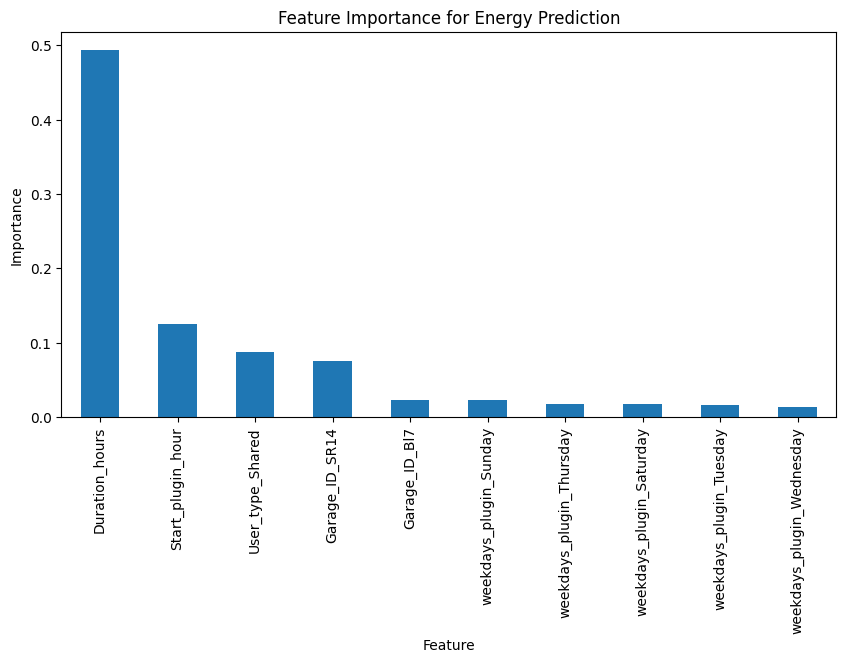

In [53]:
feature_importance.head(10).plot(kind="bar", figsize=(10,5))
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Feature Importance for Energy Prediction")

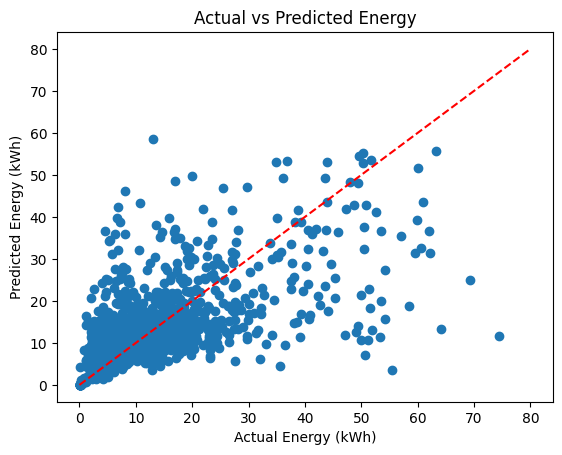

In [60]:
plt.scatter(x= y_test, y= y_pred)
plt.xlabel("Actual Energy (kWh)")
plt.ylabel("Predicted Energy (kWh)")
plt.title("Actual vs Predicted Energy")
plt.plot([0, 80], [0, 80], color ="red", linestyle= "--")
plt.show()


In [62]:
errors = abs(y_test - y_pred)
print(errors[:10])

132      0.3880
1662     6.5021
5256    44.3626
6841     0.9038
3460    10.6806
4762     6.5737
1859     3.0702
4034     7.1863
3620     2.1211
3129     9.5656
Name: El_kWh, dtype: float64


In [63]:
errors.sort_values(ascending=False)

6808    62.6894
5748    51.9485
5842    50.8248
3308    45.6005
5256    44.3626
         ...   
79       0.0031
533      0.0029
5349     0.0013
5768     0.0007
4593     0.0002
Name: El_kWh, Length: 1369, dtype: float64

In [ ]:
df_ml.loc[6808]

session_ID                             6809
Garage_ID                              AdO1
User_ID                              AdO1-4
User_type                           Private
Shared_ID                               NaN
Start_plugin            2020-01-29 20:32:00
Start_plugin_hour                        20
End_plugout             2020-01-30 07:10:00
End_plugout_hour                        7.0
El_kWh                                 74.4
Duration_hours                    10.640556
month_plugin                            Jan
weekdays_plugin                   Wednesday
Plugin_category       early evening (18-21)
Duration_category    Between 9 and 12 hours
Charging_Power_kW                  6.992116
Name: 6808, dtype: object

In [ ]:
df[["Charging_Power_kW", "El_kWh"]].corr()
# Higher charging power tends to be associated with higher energy consumption, but power alone doesn't explain the energy very well.

,Charging_Power_kW,El_kWh
Charging_Power_kW,1.000000,0.325698
El_kWh,0.325698,1.000000


In [70]:
y_train.mean()

np.float64(12.772191780821919)

In [ ]:
baseline_predictions ="For every charging session in the test set, I'll simply predict: "
print(baseline_predictions, y_train.mean())

For every charging session in the test set, I'll simply predict:  12.772191780821919


In [74]:
baseline_predictions = np.full(len(y_test), y_train.mean())
baseline_predictions[:10]

array([12.77219178, 12.77219178, 12.77219178, 12.77219178, 12.77219178,
       12.77219178, 12.77219178, 12.77219178, 12.77219178, 12.77219178])

In [76]:
baseline_errors = abs(y_test - y_train.mean())
baseline_mae = baseline_errors.mean()

print("Baseline MAE:", baseline_mae)                


Baseline MAE: 8.062122036883235


In [77]:
energy_group = pd.cut(
    y_test,
    bins=[-float("inf"), 10, 30, float("inf")],
    labels=["Low", "Medium", "High"]
)
energy_group.value_counts()

El_kWh
Low       736
Medium    531
High      102
Name: count, dtype: int64

In [78]:
error_by_group = pd.DataFrame({
    "Actual_Energy": y_test,
    "Prediction_Error": errors,
    "Energy_Group": energy_group
})

In [86]:
group_mae = error_by_group.groupby("Energy_Group")["Prediction_Error"].mean()

print(group_mae)

Energy_Group
Low        3.975550
Medium     5.402364
High      18.144694
Name: Prediction_Error, dtype: float64


In [99]:
high_energy = error_by_group[error_by_group["Energy_Group"]=="High"]

In [100]:
high_energy.head(10)

,Actual_Energy,Prediction_Error,Energy_Group
5256,69.33,44.3626,High
3129,45.96,9.5656,High
2707,43.96,9.0646,High
2939,38.15,23.3045,High
2177,40.51,8.1779,High
1242,30.23,3.3817,High
5931,40.55,16.6327,High
4767,40.60,3.6793,High
5682,38.73,2.9375,High
2718,50.89,8.0824,High


In [101]:
from sklearn.linear_model import LinearRegression

In [102]:
linear_model = LinearRegression()

In [103]:
linear_model.fit(X_train_encoded, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [106]:
linear_predictions = linear_model.predict(X_test_encoded)
linear_predictions[:10]

array([12.40310077, 15.90231148, 19.92282825, 10.92398313,  7.46358296,
       16.184724  , 18.43774842,  7.96371948, 10.96900487, 20.67003796])

In [107]:
linear_errors = abs(y_test- linear_predictions)

linear_mae = linear_errors.mean()

print("Linear Regression MAE:", linear_mae)

Linear Regression MAE: 6.88194572246672
